In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/gan-getting-started/monet_jpg/f4413e97bd.jpg
/kaggle/input/gan-getting-started/monet_jpg/7341d96c1d.jpg
/kaggle/input/gan-getting-started/monet_jpg/de6f71b00f.jpg
/kaggle/input/gan-getting-started/monet_jpg/99d94af5dd.jpg
/kaggle/input/gan-getting-started/monet_jpg/99a51d3e25.jpg
/kaggle/input/gan-getting-started/monet_jpg/d05cab011d.jpg
/kaggle/input/gan-getting-started/monet_jpg/4e05523825.jpg
/kaggle/input/gan-getting-started/monet_jpg/c68c52e8fc.jpg
/kaggle/input/gan-getting-started/monet_jpg/40d7d18ad3.jpg
/kaggle/input/gan-getting-started/monet_jpg/f96a8de9f3.jpg
/kaggle/input/gan-getting-started/monet_jpg/79224da51f.jpg
/kaggle/input/gan-getting-started/monet_jpg/23832dead5.jpg
/kaggle/input/gan-getting-started/monet_jpg/85580214be.jpg
/kaggle/input/gan-getting-started/monet_jpg/47a0548067.jpg
/kaggle/input/gan-getting-started/monet_jpg/fb93438ff9.jpg
/kaggle/input/gan-getting-started/monet_jpg/89d970411d.jpg
/kaggle/input/gan-getting-started/monet_jpg/7960adbd50.j

In [3]:
monet_path = '/kaggle/input/gan-getting-started/monet_jpg/'
photo_path = '/kaggle/input/gan-getting-started/photo_jpg/'

In [4]:
transform = transforms.Compose([
    transforms.Resize((256,256)),transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))
])

In [5]:
class MonetDataset(Dataset):
    def __init__(self, monet_dir, photo_dir, transform=None):
        self.monet_files = [os.path.join(monet_dir, f) for f in os.listdir(monet_dir)]
        self.photo_files = [os.path.join(photo_dir, f) for f in os.listdir(photo_dir)]
        self.transform = transform

    def __len__(self):
        return min(len(self.monet_files), len(self.photo_files))  # Match dataset size

    def __getitem__(self, idx):
        monet_img = Image.open(self.monet_files[idx]).convert("RGB")
        photo_img = Image.open(self.photo_files[idx]).convert("RGB")

        if self.transform:
            monet_img = self.transform(monet_img)
            photo_img = self.transform(photo_img)

        return monet_img, photo_img
        

In [6]:
#Load the data
dataset = MonetDataset(monet_path, photo_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=4)

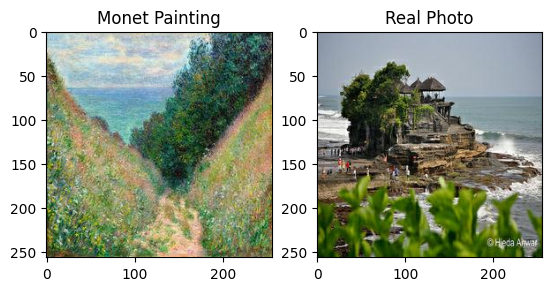

In [ ]:
#Let's visualize the data
import matplotlib.pyplot as plt
sample_monet, sample_photo = next(iter(dataloader))
fig, ax = plt.subplots(1, 2)
ax[0].imshow(sample_monet.squeeze().permute(1, 2, 0) * 0.5 + 0.5)
ax[0].set_title("Monet Painting")
ax[1].imshow(sample_photo.squeeze().permute(1, 2, 0) * 0.5 + 0.5)
ax[1].set_title("Real Photo")
plt.show()

Generator class implementation (U-Net based)

In [14]:
import torch
import torch.nn as nn
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        # Encoder (A -> B)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3),  # 1st conv layer
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 2nd conv layer with downsampling
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # 3rd conv layer with downsampling
            nn.ReLU(inplace=True),
        )

        # ResNet blocks
        self.resnet_blocks = nn.ModuleList([ResBlock(256) for _ in range(6)])

        # Decoder (A -> B)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 1st deconv layer
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 2nd deconv layer
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 3, kernel_size=7, stride=1, padding=3),  # Final output layer
            nn.Tanh()  # Output between [-1, 1] range
        )

    def forward(self, x):
        x = self.encoder(x)
        #print("After encoder:", x.shape)
        for block in self.resnet_blocks:
            x = block(x)
        x = self.decoder(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)  # Residual connection

loop = tqdm(dataloader, leave=True)
for i, (real_A, _) in enumerate(loop):  # Only use photos, ignore Monet images
        real_A = real_A.to(device)  # Real photo
#generator_A2B = Generator()  # Photo -> Monet
#generator_B2A = Generator()  # Monet -> Photo
G_A2B = Generator().to(device)  # Photo → Monet
fake_A = G_A2B(real_A)


100%|██████████| 300/300 [00:01<00:00, 269.64it/s]


In [15]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

discriminator_A = Discriminator()  # Monet Discriminator
discriminator_B = Discriminator()  # Photo Discriminator

In [16]:
def show_generated_samples(generator, real_photo, epoch):
    generator.eval() #Set the generator to evaluation mode
    with torch.no_grad():
        fake_monet = generator(real_photo.to(device)).cpu()
    #Convert tensors to displayable images
    real_photo = real_photo.squeeze().permute(1, 2, 0)*0.5 + 0.5
    fake_monet = fake_monet.squeeze().permute(1, 2, 0)*0.5 + 0.5

    #plot real & fake images
    fig, ax = plt.subplots(1, 2, figsize=(8,4))
    ax[0].imshow(real_photo.numpy())
    ax[0].set_title("Real Photo")
    ax[0].axis("off")

    ax[1].imshow(fake_monet.numpy())
    ax[1].set_title("Generated Monet Painting")
    ax[1].axis("off")

    plt.show()

Epoch [5/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=0.000121, D_loss_B=7.31e-5, G_loss_A2B=12.2, G_loss_B2A=5.39] 


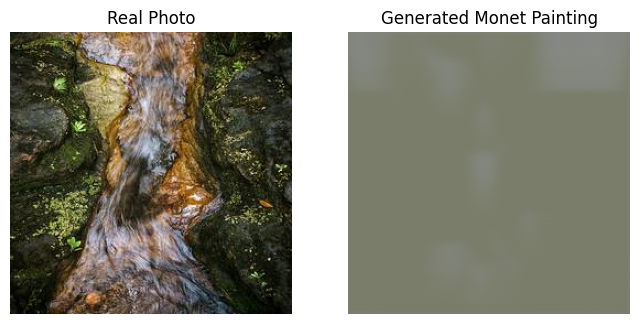

Epoch [10/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=7.89e-6, D_loss_B=2.15e-5, G_loss_A2B=12.5, G_loss_B2A=4.33] 


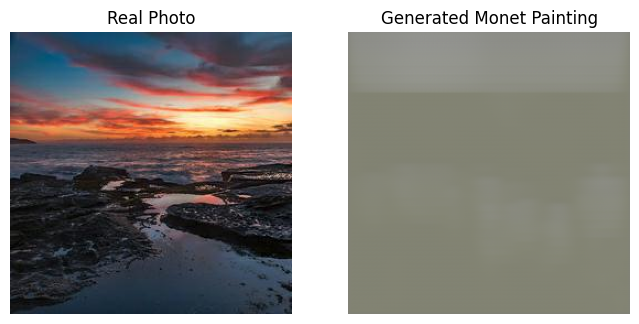

Epoch [15/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=7.51e-6, D_loss_B=8.32e-6, G_loss_A2B=12.4, G_loss_B2A=3.86]


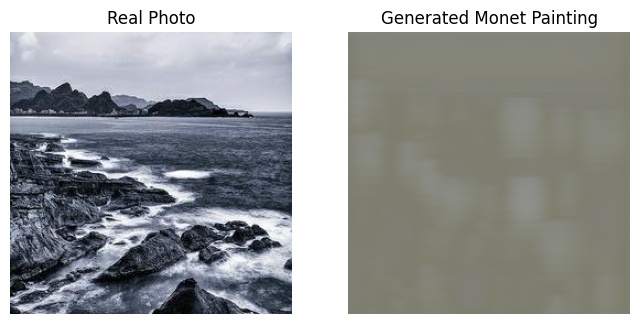

Epoch [20/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=1.1e-5, D_loss_B=3.61e-6, G_loss_A2B=12.8, G_loss_B2A=4.77]  


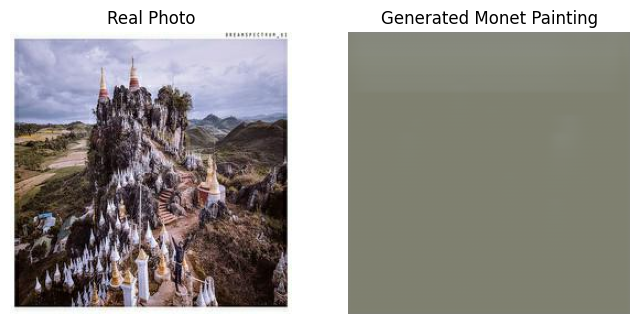

Epoch [25/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=1.65e-6, D_loss_B=2.16e-6, G_loss_A2B=12.4, G_loss_B2A=4.56] 


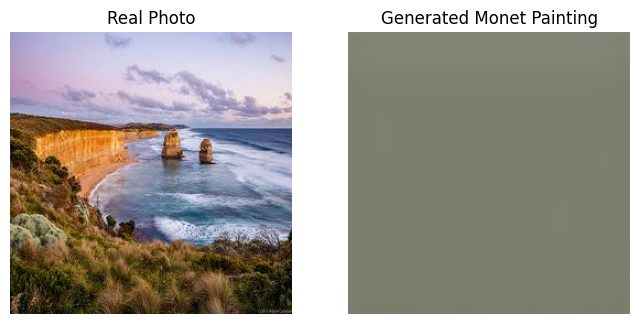

Epoch [30/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=7.08e-6, D_loss_B=1.5e-6, G_loss_A2B=12.1, G_loss_B2A=12.8] 


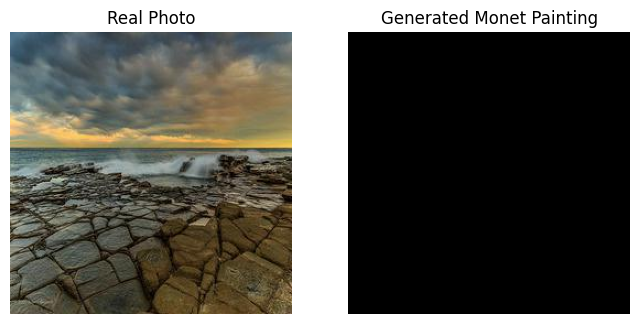

Epoch [35/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=5.14e-7, D_loss_B=7.88e-7, G_loss_A2B=8.95, G_loss_B2A=8.04]


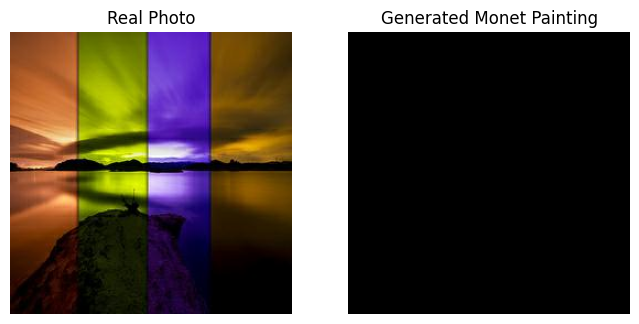

Epoch [40/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=2.15e-7, D_loss_B=2.58e-7, G_loss_A2B=12.6, G_loss_B2A=13.1]


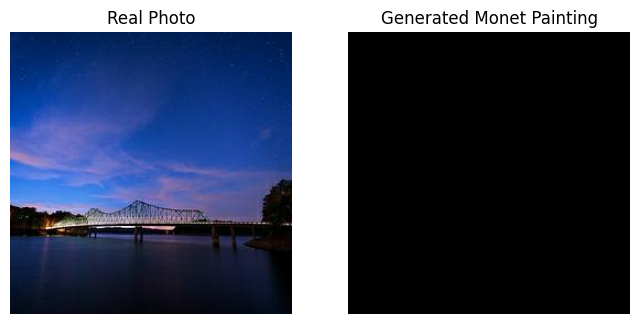

Epoch [45/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=3.53e-7, D_loss_B=5.32e-7, G_loss_A2B=12, G_loss_B2A=12.6]  


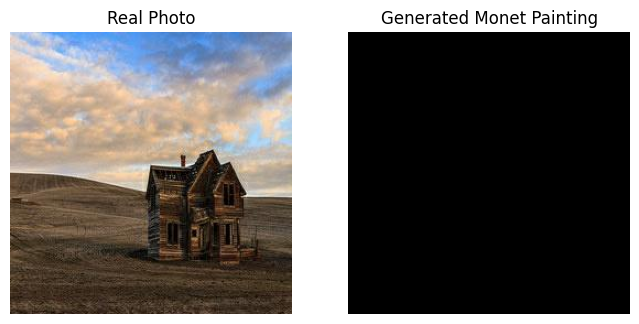

Epoch [50/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=6.88e-8, D_loss_B=2.14e-7, G_loss_A2B=14.8, G_loss_B2A=15.7]


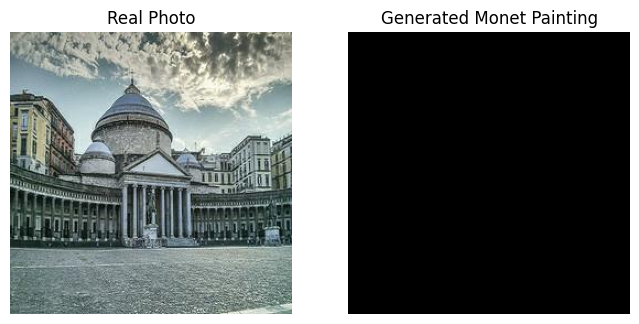

Epoch [55/100]: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, D_loss_A=6.15e-8, D_loss_B=1.37e-7, G_loss_A2B=11.9, G_loss_B2A=11.7]


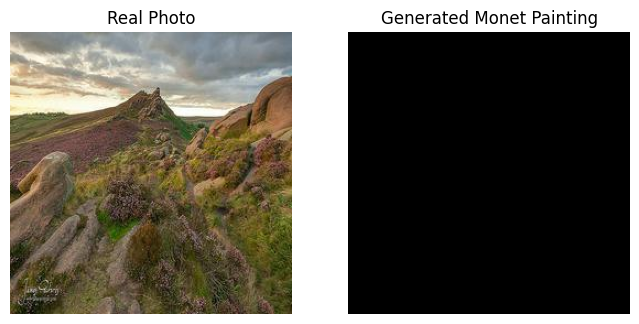

Epoch [56/100]:  21%|██        | 62/300 [00:14<00:56,  4.21it/s, D_loss_A=3.23e-8, D_loss_B=3.66e-8, G_loss_A2B=13.1, G_loss_B2A=14]  

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Generator (Photo → Monet) and Discriminator (Monet)
G_A2B = Generator().to(device)  # Photo → Monet
G_B2A = Generator().to(device)  # Monet → Photo
D_A = Discriminator().to(device)  # Monet Discriminator
D_B = Discriminator().to(device)  # Photo Discriminator

# Loss functions
criterion_GAN = nn.MSELoss()  # Adversarial loss
criterion_cycle = nn.L1Loss()  # Cycle consistency loss
criterion_identity = nn.L1Loss()  # Identity loss

# Optimizers
optimizer_G = optim.Adam(
    list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=0.0002, betas=(0.5, 0.999)
)
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training parameters
EPOCHS = 100
LAMBDA_CYCLE = 10  # Weight for cycle consistency loss (adjusted)
LAMBDA_IDENTITY = 0.5  # Weight for identity loss (adjusted)

# Training Loop
for epoch in range(EPOCHS):
    loop = tqdm(dataloader, leave=True)
    
    for i, (real_A, _) in enumerate(loop):  # Only use photos, ignore Monet images
        real_A = real_A.to(device)  # Real photo
        real_B = real_A.clone().to(device)  # Fake Monet (used for identity loss)

        ### ---- TRAIN GENERATOR (Photo → Monet) ---- ###
        optimizer_G.zero_grad()

        # Generate fake Monet from real photo
        fake_B = G_A2B(real_A)  
        pred_fake_B = D_A(fake_B)  # Discriminator result on fake Monet

        # Adversarial Loss for Generator G_A2B (Photo → Monet)
        loss_GAN_A2B = criterion_GAN(pred_fake_B, torch.ones_like(pred_fake_B))

        # Identity Loss (Monet → Monet should remain unchanged)
        identity_B = G_A2B(real_B)
        loss_identity_B = criterion_identity(real_B, identity_B) * LAMBDA_IDENTITY

        # Cycle Consistency Loss (Photo → Monet → Photo)
        rec_A = G_B2A(fake_B)  # Reconstruct photo from fake Monet (using G_B2A)
        loss_cycle_A = criterion_cycle(real_A, rec_A) * LAMBDA_CYCLE  # Apply cycle consistency weight

        # Total Generator Loss for G_A2B
        loss_G_A2B = loss_GAN_A2B + loss_cycle_A + loss_identity_B
        loss_G_A2B.backward()

        ### ---- TRAIN GENERATOR (Monet → Photo) ---- ###
        optimizer_G.zero_grad()

        # Generate fake photo from real Monet
        fake_A = G_B2A(real_B)  
        pred_fake_A = D_B(fake_A)  # Discriminator result on fake Photo

        # Adversarial Loss for Generator G_B2A (Monet → Photo)
        loss_GAN_B2A = criterion_GAN(pred_fake_A, torch.ones_like(pred_fake_A))

        # Identity Loss (Photo → Photo should remain unchanged)
        identity_A = G_B2A(real_A)
        loss_identity_A = criterion_identity(real_A, identity_A) * LAMBDA_IDENTITY

        # Cycle Consistency Loss (Monet → Photo → Monet)
        rec_B = G_A2B(fake_A)  # Reconstruct Monet from fake photo (using G_A2B)
        loss_cycle_B = criterion_cycle(real_B, rec_B) * LAMBDA_CYCLE  # Apply cycle consistency weight

        # Total Generator Loss for G_B2A
        loss_G_B2A = loss_GAN_B2A + loss_cycle_B + loss_identity_A
        loss_G_B2A.backward()

        # Now update both generators
        optimizer_G.step()

        ### ---- TRAIN DISCRIMINATOR (Monet) ---- ###
        optimizer_D_A.zero_grad()

        # Discriminator Loss: Real Monet
        pred_real_B = D_A(real_B)
        loss_D_real_B = criterion_GAN(pred_real_B, torch.ones_like(pred_real_B))

        # Discriminator Loss: Fake Monet
        pred_fake_B = D_A(fake_B.detach())  # Stop gradient on generator
        loss_D_fake_B = criterion_GAN(pred_fake_B, torch.zeros_like(pred_fake_B))

        # Total Discriminator Loss for D_A (Monet Discriminator)
        loss_D_A = (loss_D_real_B + loss_D_fake_B) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()

        ### ---- TRAIN DISCRIMINATOR (Photo) ---- ###
        optimizer_D_B.zero_grad()

        # Discriminator Loss: Real Photo
        pred_real_A = D_B(real_A)
        loss_D_real_A = criterion_GAN(pred_real_A, torch.ones_like(pred_real_A))

        # Discriminator Loss: Fake Photo
        pred_fake_A = D_B(fake_A.detach())  # Stop gradient on generator
        loss_D_fake_A = criterion_GAN(pred_fake_A, torch.zeros_like(pred_fake_A))

        # Total Discriminator Loss for D_B (Photo Discriminator)
        loss_D_B = (loss_D_real_A + loss_D_fake_A) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()

        ### ---- Update Progress Bar ---- ###
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(
            G_loss_A2B=loss_G_A2B.item(), G_loss_B2A=loss_G_B2A.item(), D_loss_A=loss_D_A.item(), D_loss_B=loss_D_B.item()
        )
    
    # Save and show generated samples periodically (every 5 epochs, for example)
    if (epoch + 1) % 5 == 0:
        _, real_photo_sample = next(iter(dataloader))
        show_generated_samples(G_A2B, real_photo_sample[:1], epoch + 1)
    
    # Save checkpoints every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(G_A2B.state_dict(), f"generator_photo2monet_epoch{epoch+1}.pth")
        torch.save(G_B2A.state_dict(), f"generator_monet2photo_epoch{epoch+1}.pth")
        torch.save(D_A.state_dict(), f"discriminator_monet_epoch{epoch+1}.pth")
        torch.save(D_B.state_dict(), f"discriminator_photo_epoch{epoch+1}.pth")


In [ ]:
# Generate and save images
from torchvision.utils import save_image
for i in range(100):
    _, real_photo_sample = next(iter(dataloader))
    fake_image = G_A2B(real_photo_sample.to(device)).cpu()
    output_dir = "/kaggle/working/"
    save_path = os.path.join(output_dir, f"image_{i:04}.png")
    save_image(fake_image, save_path, normalize=True)

with ZipFile(zip_filename, 'w') as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, output_dir))    